
# Explicabilidad SHAP - ETHUSDT (residual_hybrid *staged*, bloque `sentiment`)

Modelo congelado de ETHUSDT con familia `residual_hybrid`, etiquetado
`fixed_horizon` e **inyección del bloque `sentiment`** en stage1 (LSTM). El
corrector XGBoost (stage2) recibe las dos columnas `reddit_*` del bloque activo
más las seis señales del LSTM stage1 (**8** features en total).


In [14]:

from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (
    REPO_ROOT / "src" / "validation" / "model_explainability.py"
).exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "validation" / "model_explainability.py").exists():
    raise SystemExit("No se localiza la raíz del repo del TFG.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROMOTION_MANIFEST = REPO_ROOT / "reports/validation/promotion/20260520T153716Z/promotion_manifest.json"
EXPL_REPORT_ROOT = REPO_ROOT / "reports" / "validation" / "explainability"
EXPL_REPORT_ROOT.mkdir(parents=True, exist_ok=True)


In [15]:

SYMBOL = "ETHUSDT"

from src.validation.model_explainability import (
    align_xgb_proba,
    build_corrector_input,
    build_sequence_windows,
    compute_lstm_signal_features,
    explain_corrector_kernel_shap,
    load_fold_datasets,
    load_promotion_champions,
    load_residual_hybrid_pair,
    load_simple_lstm_classifier,
    predict_lstm_softmax,
)

handles = load_promotion_champions(PROMOTION_MANIFEST, repo_root=REPO_ROOT)
handle = handles[SYMBOL]

SYMBOL_REPORT_DIR = EXPL_REPORT_ROOT / SYMBOL.lower()
SYMBOL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Símbolo          :", handle.symbol)
print("Carril           :", handle.lane)
print("Familia          :", handle.family)
print("Familia_motor    :", handle.engine_family)
print("Etiquetado       :", handle.labeling_method)
print("Inyección        :", handle.injection_strategy)
print("Bloques_activos  :", handle.active_blocks_id)
print("Id_estudio       :", handle.study_id)
print("Dir_ultimo_fold  :", handle.last_fold_dir.relative_to(REPO_ROOT).as_posix())
print("Dir_modelos_fold:", handle.fold_models_dir.relative_to(REPO_ROOT).as_posix())
print("Canales          :", len(handle.feature_channel_order))
print("Barras_lookback  :", handle.lookback_bars)


Símbolo          : ETHUSDT
Carril           : primary
Familia          : residual_hybrid
Familia_motor    : residual_hybrid
Etiquetado       : fixed_horizon
Inyección        : staged
Bloques_activos  : sentiment
Id_estudio       : greedy_ethusdt_fixed_horizon_residual_hybrid_staged_sentiment_20260505T012242Z_frozen_20260517T134241Z
Dir_ultimo_fold  : reports/validation/experiments/greedy_ethusdt_fixed_horizon_residual_hybrid_staged_sentiment_20260505T012242Z_frozen_20260517T134241Z/folds/fold_096
Dir_modelos_fold: reports/validation/experiments/greedy_ethusdt_fixed_horizon_residual_hybrid_staged_sentiment_20260505T012242Z_frozen_20260517T134241Z/folds/fold_096/models/residual_hybrid
Canales          : 19
Barras_lookback  : 42


## 1. Datos del *fold* congelado y tensorización causal


In [16]:

datasets = load_fold_datasets(handle)
train_df, test_df = datasets["train"], datasets["test"]
print("Filas entrenamiento:", train_df.shape, "| filas test:", test_df.shape)

windowed = build_sequence_windows(
    train_df,
    test_df,
    feature_channel_order=handle.feature_channel_order,
    lookback_bars=handle.lookback_bars,
)
X_train, X_test = windowed["X_train"], windowed["X_test"]
y_train, y_test = windowed["y_train"], windowed["y_test"]
aligned_train = windowed["aligned_train"]
aligned_test = windowed["aligned_test"]
feature_channels = list(windowed["feature_channel_order"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train cuenta:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test  cuenta:", dict(zip(*np.unique(y_test, return_counts=True))))


Filas entrenamiento: (1080, 49) | filas test: (180, 49)
X_train: (1039, 42, 19) | X_test: (180, 42, 19)
y_train cuenta: {0: 420, 1: 181, 2: 438}
y_test  cuenta: {0: 90, 1: 29, 2: 61}



## 2. Stage1 LSTM + stage2 XGBoost: matriz completa de entrada al corrector

El stage1 (LSTM) se carga desde el `lstm_stage1_state.pt` del *refit* oficial,
genera las probabilidades por clase y deriva las seis señales
`lstm_proba_side_*`, `lstm_margin`, `lstm_confidence`, `lstm_entropy`.
El corrector XGBoost (stage2) recibe la concatenación de
`corrector_base_feature_columns` -> seis señales LSTM en el orden exacto
declarado por `stage2_feature_columns` en el manifiesto del *fold*. Para BNBUSDT
la lista base está vacía (solo seis señales); para ETHUSDT y SOLUSDT incluye
además las columnas del bloque activo (`sentiment` o `derivatives_futures`).


In [17]:

import xgboost  # noqa: F401 - necesario para deserializar model_state.joblib

lstm_model, corrector, residual_manifest = load_residual_hybrid_pair(handle)

stage1_proba_train = predict_lstm_softmax(lstm_model, X_train)
stage1_proba_test = predict_lstm_softmax(lstm_model, X_test)
signal_train = compute_lstm_signal_features(stage1_proba_train).reset_index(drop=True)
signal_test = compute_lstm_signal_features(stage1_proba_test).reset_index(drop=True)

corrector_input_train = build_corrector_input(
    aligned_train.reset_index(drop=True), signal_train, residual_manifest,
)
corrector_input_test = build_corrector_input(
    aligned_test.reset_index(drop=True), signal_test, residual_manifest,
)
corrector_feature_names = list(corrector_input_test.columns)

print("Stage2_feature_columns:", residual_manifest["stage2_feature_columns"])
print("Corrector_base_feature_columns:", residual_manifest["corrector_base_feature_columns"])
print("Corrector_input_train shape:", corrector_input_train.shape)
print("Corrector_input_test  shape:", corrector_input_test.shape)
corrector_input_test.describe().T


Stage2_feature_columns: ['reddit_sentiment_mean', 'reddit_sentiment_mean_lag_1', 'lstm_proba_side_neg', 'lstm_proba_side_neutral', 'lstm_proba_side_pos', 'lstm_margin', 'lstm_confidence', 'lstm_entropy']
Corrector_base_feature_columns: ['reddit_sentiment_mean', 'reddit_sentiment_mean_lag_1']
Corrector_input_train shape: (1039, 8)
Corrector_input_test  shape: (180, 8)


,count,mean,std,min,25%,50%,75%,max
reddit_sentiment_mean,180.0,-0.092349,0.797811,-1.853979,-0.562911,-0.020051,0.343229,1.931866
reddit_sentiment_mean_lag_1,180.0,-0.083618,0.788095,-1.853982,-0.550768,-0.019345,0.344075,1.933325
lstm_proba_side_neg,180.0,0.345385,0.158555,0.029382,0.219064,0.346537,0.457274,0.710068
lstm_proba_side_neutral,180.0,0.226484,0.140657,0.076743,0.133887,0.174313,0.286075,0.722229
lstm_proba_side_pos,180.0,0.428131,0.137767,0.153239,0.319018,0.428118,0.521649,0.722883
lstm_margin,180.0,0.211387,0.146984,0.000938,0.085906,0.174236,0.310969,0.563767
lstm_confidence,180.0,0.526492,0.089422,0.353158,0.450890,0.511503,0.588511,0.722883
lstm_entropy,180.0,0.967794,0.084008,0.734076,0.912478,0.981774,1.031587,1.095664


## 3. SHAP del stage1 LSTM (canales técnicos)

Aplicamos `shap.GradientExplainer` sobre el LSTM congelado del stage1 con un
*background* de 50 ventanas de entrenamiento y explicamos las primeras ~120
ventanas de evaluación. Esto nos da la atribución por **canal técnico** y
por **desplazamiento temporal**, complementaria al SHAP del corrector
(sección 4) que opera sobre las seis señales `lstm_*` (más, en su caso, las
columnas del bloque contextual activo).


In [18]:
import shap
import torch

SEED_STAGE1 = 17
rng_stage1 = np.random.default_rng(SEED_STAGE1)
stage1_background_size = min(50, X_train.shape[0])
stage1_explain_size = min(120, X_test.shape[0])

bg_idx_s1 = rng_stage1.choice(X_train.shape[0], size=stage1_background_size, replace=False)
ex_idx_s1 = np.arange(stage1_explain_size)

background_tensor_s1 = torch.from_numpy(X_train[bg_idx_s1]).float()
explain_tensor_s1 = torch.from_numpy(X_test[ex_idx_s1]).float()

lstm_model.eval()
explainer_s1 = shap.GradientExplainer(lstm_model, background_tensor_s1)
shap_values_s1 = explainer_s1.shap_values(explain_tensor_s1)
if isinstance(shap_values_s1, np.ndarray) and shap_values_s1.ndim == 4:
    shap_values_s1 = [shap_values_s1[..., k] for k in range(shap_values_s1.shape[-1])]

class_labels_s1 = [-1, 0, 1]
stage1_shap_by_class = {label: np.asarray(shap_values_s1[idx]) for idx, label in enumerate(class_labels_s1)}
print("Stage1 - n clases:", len(stage1_shap_by_class))
print("Stage1 - shape por clase:", {k: v.shape for k, v in stage1_shap_by_class.items()})


Stage1 - n clases: 3
Stage1 - shape por clase: {-1: (120, 42, 19), 0: (120, 42, 19), 1: (120, 42, 19)}


### 3.1 Importancia agregada por canal


In [19]:
stage1_feature_importance = {
    label: np.mean(np.abs(sv), axis=(0, 1)) for label, sv in stage1_shap_by_class.items()
}
stage1_importance_df = pd.DataFrame(stage1_feature_importance, index=feature_channels)
stage1_importance_df.columns = [f"clase_{c:+d}" for c in stage1_importance_df.columns]
stage1_importance_df["total"] = stage1_importance_df.abs().sum(axis=1)
stage1_importance_df = stage1_importance_df.sort_values("total", ascending=False)
stage1_importance_df.head(20)


,clase_-1,clase_+0,clase_+1,total
vol_sma_ratio_20,0.013816,0.006330,0.008225,0.028372
num_trades,0.011856,0.005787,0.007858,0.025502
rolling_std_20,0.010607,0.004602,0.006778,0.021987
atr_14,0.008578,0.004203,0.005698,0.018478
pvt,0.009143,0.001985,0.007118,0.018246
ema_26,0.006112,0.002831,0.004808,0.013751
bbands_pctb_20,0.005138,0.003768,0.004119,0.013025
macd_hist,0.005728,0.002839,0.003068,0.011634
taker_buy_asset_volume,0.003959,0.002213,0.003571,0.009743
roc_12,0.004088,0.002562,0.002694,0.009344


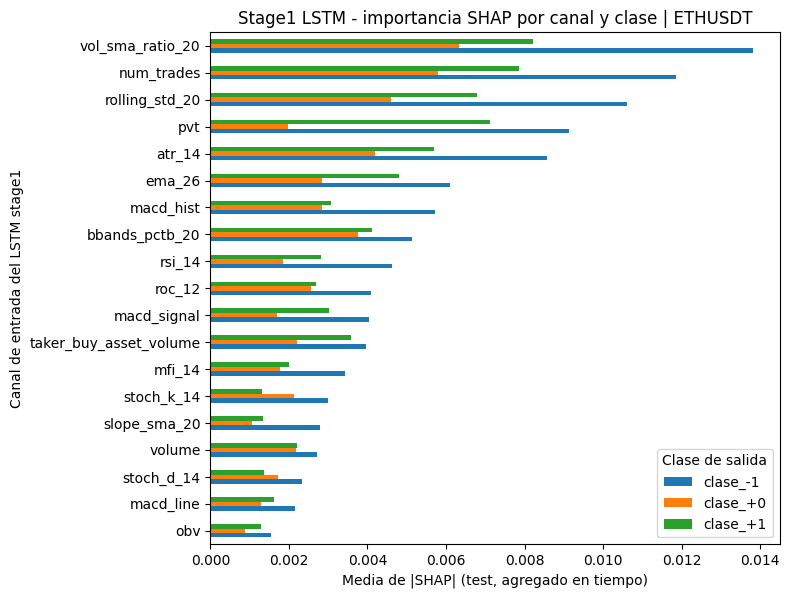

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(feature_channels))))
plot_df_s1 = stage1_importance_df.drop(columns="total").sort_values(by=stage1_importance_df.columns[0])
plot_df_s1.plot(kind="barh", ax=ax)
ax.set_xlabel("Media de |SHAP| (test, agregado en tiempo)")
ax.set_ylabel("Canal de entrada del LSTM stage1")
ax.set_title(f"Stage1 LSTM - importancia SHAP por canal y clase | {SYMBOL}")
ax.legend(title="Clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_feature_importance.png", dpi=140)
plt.show()


### 3.2 Atribución temporal del stage1 (donde mira el LSTM dentro de la ventana)


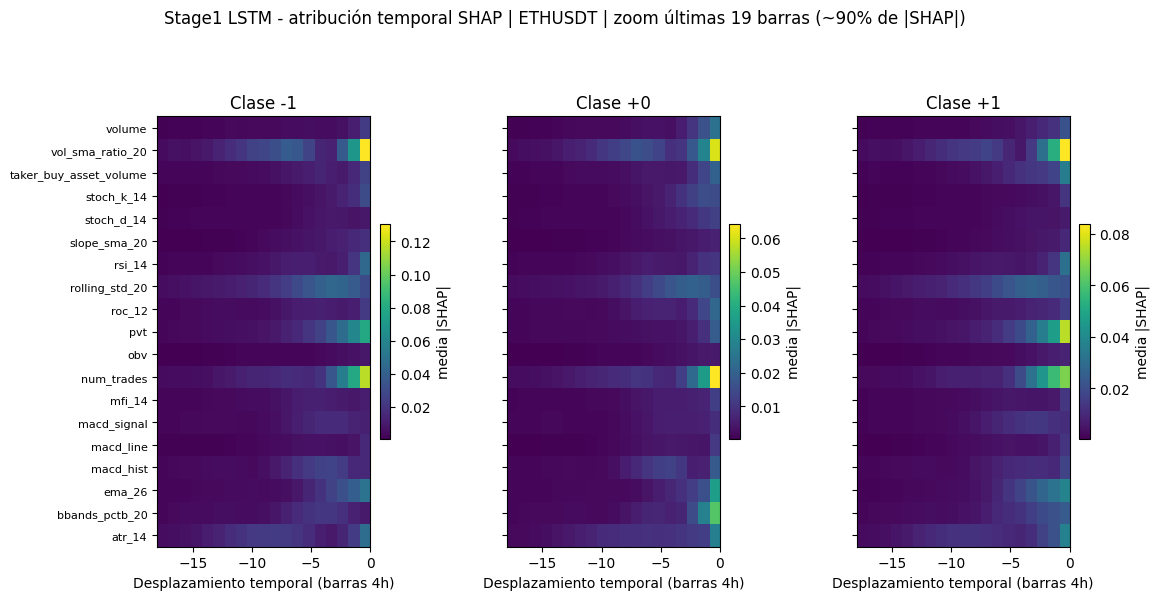

In [21]:
stage1_time_attr = {label: np.mean(np.abs(sv), axis=0) for label, sv in stage1_shap_by_class.items()}

lookback_s1 = int(handle.lookback_bars)
lag_labels_s1 = np.arange(-lookback_s1 + 1, 1)

stacked_s1 = np.stack(list(stage1_time_attr.values()), axis=0)
time_profile_s1 = np.mean(stacked_s1, axis=(0, 2))
total_mass_s1 = float(time_profile_s1.sum())
if total_mass_s1 > 0.0:
    cum_recent_s1 = np.cumsum(time_profile_s1[::-1])
    recent_bars_s1 = int(np.searchsorted(cum_recent_s1 / total_mass_s1, 0.90)) + 1
else:
    recent_bars_s1 = lookback_s1
recent_bars_s1 = int(np.clip(recent_bars_s1, min(10, lookback_s1), lookback_s1))
start_idx_s1 = lookback_s1 - recent_bars_s1
mass_pct_s1 = 100.0 * float(time_profile_s1[start_idx_s1:].sum() / max(total_mass_s1, 1e-12))
x_min_s1, x_max_s1 = int(lag_labels_s1[start_idx_s1]), 0

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, max(4.0, 0.32 * len(feature_channels))),
    sharey=True,
)
for ax, (label, mat) in zip(axes, stage1_time_attr.items()):
    mat_zoom = mat[start_idx_s1:, :]
    im = ax.imshow(
        mat_zoom.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[x_min_s1, x_max_s1, -0.5, len(feature_channels) - 0.5],
    )
    ax.set_title(f"Clase {label:+d}")
    ax.set_xlabel("Desplazamiento temporal (barras 4h)")
    ax.set_yticks(range(len(feature_channels)))
    ax.set_yticklabels(feature_channels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="media |SHAP|")
fig.suptitle(
    f"Stage1 LSTM - atribución temporal SHAP | {SYMBOL} | "
    f"zoom últimas {recent_bars_s1} barras (~{mass_pct_s1:.0f}% de |SHAP|)"
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(left=0.16, wspace=0.5)
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_time_heatmap.png", dpi=140)
plt.show()



## 4. SHAP del stage2 corrector


In [22]:

import matplotlib.pyplot as plt
import numpy as np

corrector_raw_proba_test = corrector.predict_proba(
    corrector_input_test.to_numpy(dtype=np.float32)
)
corrector_proba_test = align_xgb_proba(corrector, corrector_raw_proba_test)
corrector_pred_test = np.array([-1, 0, 1])[np.argmax(corrector_proba_test, axis=1)]
corrector_conf_test = corrector_proba_test.max(axis=1)
print("Corrector classes_:", getattr(corrector, "classes_", None))
print("Predicciones del corrector en test:", dict(zip(*np.unique(corrector_pred_test, return_counts=True))))

BG_SIZE = min(50, len(corrector_input_train))
N_EXPLAIN = min(120, len(corrector_input_test))
NSAMPLES = 200

explain_set = corrector_input_test.iloc[:N_EXPLAIN].reset_index(drop=True)
explanation = explain_corrector_kernel_shap(
    corrector,
    background=corrector_input_train,
    explain=explain_set,
    nsamples=NSAMPLES,
    random_state=17,
)
shap_by_class = explanation["shap_by_class"]
print("Clases SHAP:", list(shap_by_class.keys()))
print("Shape por clase:", {k: v.shape for k, v in shap_by_class.items()})


Corrector classes_: [0 1 2]
Predicciones del corrector en test: {-1: 126, 0: 25, 1: 29}
Clases SHAP: [-1, 0, 1]
Shape por clase: {-1: (120, 8), 0: (120, 8), 1: (120, 8)}


### 4.1 Importancia agregada por señal (corrector)


In [23]:

import pandas as pd

feature_importance = {
    label: np.mean(np.abs(sv), axis=0) for label, sv in shap_by_class.items()
}
importance_df = pd.DataFrame(feature_importance, index=corrector_feature_names)
importance_df.columns = [f"clase_{c:+d}" for c in importance_df.columns]
importance_df["total"] = importance_df.abs().sum(axis=1)
importance_df = importance_df.sort_values("total", ascending=False)
importance_df


,clase_-1,clase_+0,clase_+1,total
lstm_entropy,0.039751,0.062805,0.034780,0.137336
lstm_proba_side_neutral,0.061786,0.032816,0.036501,0.131103
reddit_sentiment_mean_lag_1,0.039831,0.028339,0.040304,0.108475
lstm_proba_side_neg,0.040828,0.044652,0.009252,0.094731
reddit_sentiment_mean,0.029592,0.024298,0.035673,0.089563
lstm_proba_side_pos,0.037887,0.013394,0.029021,0.080302
lstm_margin,0.024406,0.011281,0.017713,0.053399
lstm_confidence,0.020392,0.006740,0.015867,0.042998


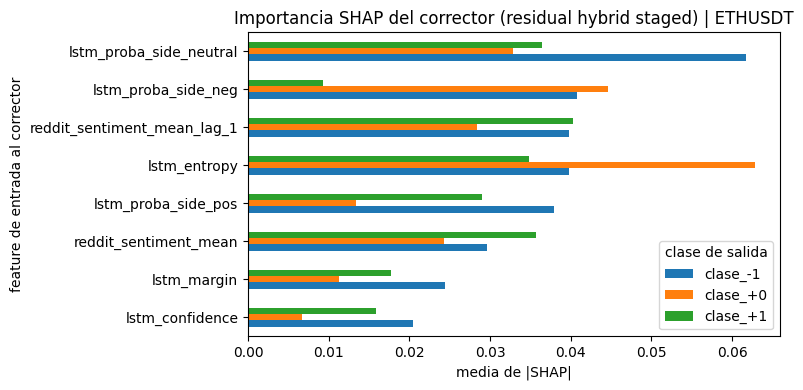

In [24]:

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(corrector_feature_names))))
plot_df = importance_df.drop(columns="total").sort_values(by=importance_df.columns[0])
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("media de |SHAP|")
ax.set_ylabel("feature de entrada al corrector")
ax.set_title(f"Importancia SHAP del corrector (residual hybrid staged) | {SYMBOL}")
ax.legend(title="clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_feature_importance.png", dpi=140)
plt.show()


### 4.2 Beeswarm SHAP por clase (corrector)


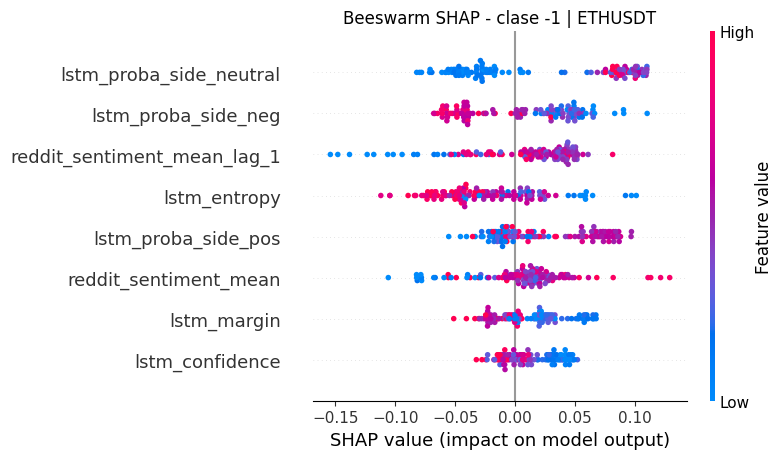

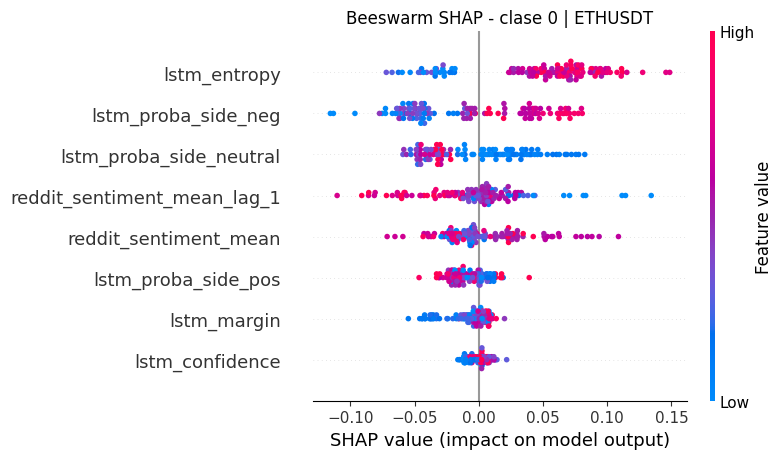

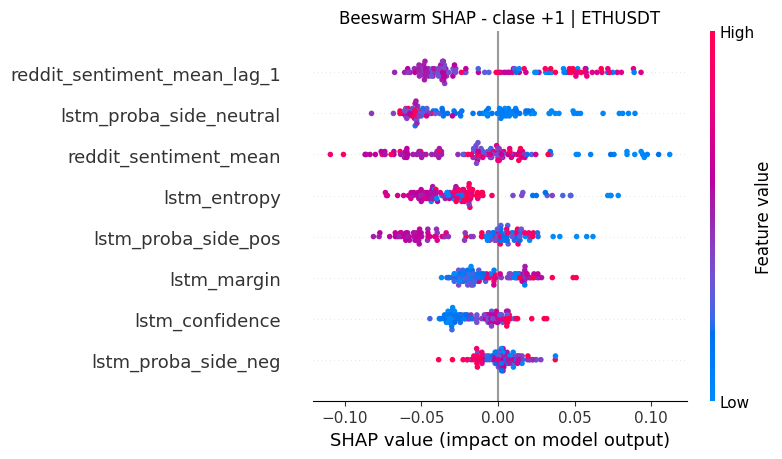

In [25]:

def _save_beeswarm(label_idx: int, label_name: str):
    import shap
    fig = plt.figure(figsize=(7, max(3.5, 0.32 * len(corrector_feature_names))))
    shap.summary_plot(
        shap_by_class[label_idx],
        explain_set,
        feature_names=corrector_feature_names,
        show=False,
    )
    plt.title(f"Beeswarm SHAP - clase {label_name} | {SYMBOL}")
    plt.tight_layout()
    out_path = SYMBOL_REPORT_DIR / (
        "shap_beeswarm_class_" + label_name.replace("+", "p").replace("-", "m") + ".png"
    )
    fig.savefig(out_path, dpi=140)
    plt.show()

for lbl, name in [(-1, "-1"), (0, "0"), (1, "+1")]:
    _save_beeswarm(lbl, name)


## 5. Persistencia de evidencias

Artefactos exportados bajo `reports/validation/explainability/ethusdt/`:

- `shap_summary.json`
- `shap_stage1_feature_importance.png`, `shap_stage1_time_heatmap.png`
- `shap_feature_importance.png`
- `shap_beeswarm_class_m1.png`, `shap_beeswarm_class_0.png`, `shap_beeswarm_class_p1.png`


In [26]:

top_per_class = {}
for label in [-1, 0, 1]:
    col = f"clase_{label:+d}"
    top_per_class[str(label)] = (
        importance_df[[col]].sort_values(col, ascending=False).reset_index().rename(columns={"index": "feature", col: "mean_abs_shap"}).to_dict(orient="records")
    )

shap_summary = {
    "symbol": handle.symbol,
    "family": handle.family,
    "engine_family": handle.engine_family,
    "lane": handle.lane,
    "active_blocks_id": handle.active_blocks_id,
    "labeling_method": handle.labeling_method,
    "study_id": handle.study_id,
    "last_fold_dir": handle.last_fold_dir.relative_to(REPO_ROOT).as_posix(),
    "n_test_windows": int(corrector_input_test.shape[0]),
    "n_explained": int(explanation["n_explained"]),
    "n_background": int(explanation["background_size"]),
    "n_corrector_features": len(corrector_feature_names),
    "explainer": "KernelExplainer (predict_proba)",
    "stage1_feature_columns": list(handle.feature_channel_order),
    "stage2_feature_columns": list(corrector_feature_names),
    "corrector_base_feature_columns": list(residual_manifest.get("corrector_base_feature_columns") or []),
    "stage1_feature_importance": stage1_importance_df.to_dict(orient="index"),
    "stage1_top_features_per_class": {
        str(label): (
            stage1_importance_df[[f"clase_{label:+d}"]]
            .sort_values(f"clase_{label:+d}", ascending=False)
            .head(5)
            .reset_index()
            .rename(columns={"index": "feature", f"clase_{label:+d}": "mean_abs_shap"})
            .to_dict(orient="records")
        )
        for label in [-1, 0, 1]
    },
    "stage2_feature_importance": importance_df.to_dict(orient="index"),
    "stage2_top_features_per_class": top_per_class,
    "feature_importance": importance_df.to_dict(orient="index"),
    "top_features_per_class": top_per_class,
    "stage1_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(np.array([-1,0,1])[np.argmax(stage1_proba_test, axis=1)], return_counts=True))},
    "stage2_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(corrector_pred_test, return_counts=True))},
    "stage2_confidence_p50": float(np.median(corrector_conf_test)),
    "stage2_confidence_p90": float(np.quantile(corrector_conf_test, 0.9)),
}
out_path = SYMBOL_REPORT_DIR / "shap_summary.json"
out_path.write_text(json.dumps(shap_summary, indent=2, default=float), encoding="utf-8")
print("Reporte persistido en", out_path.relative_to(REPO_ROOT))


Reporte persistido en reports/validation/explainability/ethusdt/shap_summary.json


## 6. Lectura cualitativa ETHUSDT (stage1 + stage2)

En ETH el corrector **invierte** la decisión del LSTM apoyándose en el bloque `sentiment`.

### Stage1 LSTM: backbone técnico ligeramente alcista

- **Predicciones del LSTM**: -1/0/+1 = 60/22/98 (sesgo alcista débil, 54 % de ventanas en +1).
- **Magnitudes |SHAP|**: orden 1e-2 (aprox. 10× las de BNB) -> el LSTM **no está saturado**: hay variabilidad real en su decisión.
- **Top canales por clase** (stage1):
  - `+1`: `vol_sma_ratio_20`, `num_trades`, `pvt`, `rolling_std_20`, `atr_14`.
  - `-1`: `vol_sma_ratio_20`, `num_trades`, `rolling_std_20`, `pvt`, `atr_14`.
  - `0`: mismos canales con magnitudes menores cambiando `pvt` por `bbands_pctb_20`.
- **Lectura**: el LSTM apoya su decisión en **volatilidad relativa al volumen y microestructura de trades**, no en osciladores clásicos (RSI/MACD están fuera del top-5). Es coherente con el carácter de ETH: liquidez profunda y sensibilidad a régimen de actividad.

### Stage2 corrector: moderador con contexto Reddit

- **Predicciones del corrector**: -1/0/+1 = 126/25/29 (sesgo bajista fuerte, 70 % de ventanas en -1).
- **Confianza**: p50 = 0.53; p90 = 0.70 (moderada, no saturada).
- **Top features SHAP por clase** (stage2):
  - `+1`: `reddit_sentiment_mean_lag_1` (0.040), `lstm_proba_side_neutral` (0.037), `reddit_sentiment_mean` (0.036), `lstm_entropy` (0.035), `lstm_proba_side_pos` (0.029).
  - `-1`: `lstm_proba_side_neutral` (0.062), `lstm_proba_side_neg` (0.041), `reddit_sentiment_mean_lag_1` (0.040), `lstm_entropy` (0.040), `lstm_proba_side_pos` (0.038).
  - `0`: `lstm_entropy` (0.063), `lstm_proba_side_neg` (0.045), `lstm_proba_side_neutral` (0.033), `reddit_sentiment_mean_lag_1` (0.028), `reddit_sentiment_mean` (0.024).
- **Lectura**: `reddit_sentiment_mean_lag_1` aparece **en el top-3 de las tres clases**, con magnitud comparable a las señales `lstm_*`. Para activar `+1` el corrector exige sentimiento Reddit positivo (con un *lag* de una barra); para activar `-1` se conforma con neutralidad LSTM y sentimiento negativo. La entropía del LSTM gobierna la clase neutral: cuando el backbone duda, el corrector se abstiene.

### Cadena causal completa

`vol_sma_ratio_20` + `num_trades` + `rolling_std_20` -> LSTM (stage1, ligeramente alcista 98/60) -> seis señales `lstm_*` + `reddit_sentiment_mean*` -> corrector (stage2, bajista 126/29). El sentimiento Reddit con *lag* es el factor que **invierte el signo** de la decisión final. Esto justifica empíricamente la elección del bloque `sentiment` en la búsqueda *greedy* y demuestra que la inyección *staged* sobre ETH no es decorativa: aporta información ortogonal al precio que el corrector aprende a usar de forma direccional.

La promoción de ETH se sostiene en la **complementariedad genuina** entre las dos etapas. El LSTM aporta el sesgo de régimen técnico (volatilidad + volumen); el corrector lo recalibra con sentimiento agregado de la comunidad cripto. Sin el SHAP del stage1 no se podría afirmar que el LSTM tiene contenido informativo propio (no saturado); sin el SHAP del stage2 no se podría aislar el efecto Reddit. La cadena solo es auditable con ambas vistas.
